In [10]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
import json
import re
from tqdm import tqdm
from itertools import combinations
from numpy import array, float32

In [11]:
models = {
    'Qwen2.5-7B-Instruct': 'qwen7b',
    'Llama-3.2-3B-Instruct': 'llama3b',
    'Llama-3.1-8B-Instruct': 'llama8b',
}
model_names = {v: k for k, v in models.items()}
seeds = ["264759", "4960273", "738294", "4625", "912345"]

In [12]:
liwc_metrics = [
 'liwc-social_social',
 'liwc-social_family',
 'liwc-bio_health',
 'liwc-drives_drives',
 'liwc-drives_achieve',
 'liwc-drives_power',
 'liwc-lifestyle_work',
 'liwc-lifestyle_leisure',
]
vad_metrics = [
    'vad-valence_valencefull', 
    'vad-arousal_arousalfull', 
    'vad-dominance_dominancefull', 
]
scm_metrics = [
    'scm-SCM_warmth',
    'scm-SCM_competence'
]
metrics_map = {
    'affect': 'affective processes',
    'social': 'social processes',
    'family': 'family',
    'tentat': 'tentative',
    'health': 'health',
    'drives': 'drives',
    'achieve': 'achievement',
    'power': 'power',
    'work': 'work',
    'leisure': 'leisure',
    'valencefull': 'valence',
    'arousalfull': 'arousal',
    'dominancefull': 'dominance',
    'warmth': 'warmth',
    'competence': 'competence'
}
metrics = liwc_metrics + vad_metrics + scm_metrics

In [13]:
all_base_values = {}
all_interview_values = {}
for model, modelshort in models.items():
    temp_base, temp_interview = [], []
    for seed in seeds:
        with open(f'../summary_emotions/{model}_baseline_{seed}.json', 'r') as f:
            data = json.load(f)
        new_df_base, new_df_interview = [], []
        for idx, row in data.items():
            if 'liwc' in row['base_scores']:
                temp_interview2 = {"id": idx, 'race': row['race'], 'gender': row['gender']}
                temp_base2 = {"id": idx, 'race': row['race'], 'gender': row['gender']}
                interview_vals = row['interview_scores']
                base_vals = row['base_scores']
                for key, val in base_vals.items():
                    for k, v in val.items():
                        for kk, vv in v.items():
                            temp_interview2[f"{key}-{k}_{kk}"] = interview_vals[key][k][kk]
                            temp_base2[f"{key}-{k}_{kk}"] = vv
                new_df_interview.append(temp_interview2)
                new_df_base.append(temp_base2)
        new_df_interview = pd.DataFrame(new_df_interview)
        new_df_base = pd.DataFrame(new_df_base)
        temp_base.append(new_df_base)
        temp_interview.append(new_df_interview)
    all_base_values[modelshort] = temp_base
    all_interview_values[modelshort] = temp_interview

In [14]:
all_metrics = [x  for x in list(all_base_values['qwen7b'][0].keys()) if x not in ['id', 'race', 'gender']]

In [15]:
def get_values(model, gender, race):
    base_df = (
        pd.concat(all_base_values[model])
          .groupby(["id", 'race', 'gender'], as_index=False)
          .mean(numeric_only=True)
    )
    interview_df = (
        pd.concat(all_interview_values[model])
          .groupby(["id", 'race', 'gender'], as_index=False)
          .mean(numeric_only=True)
    )
    keys = ['id', 'race', 'gender']
    interview_df = interview_df.rename(columns={col: f"interview_{col}" for col in interview_df.columns if col not in keys})
    df = base_df.merge(interview_df, on=keys, how="left")
    if gender is not None:
        df = df[df['gender'] == gender]
    if race is not None:
        df = df[df['race'] == race]
    values = []    
    for idx, row in df.iterrows():
        values.append({metric: (row[metric]-row[f"interview_{metric}"])*2/(abs(row[f"interview_{metric}"]) + abs(row[metric])) if (abs(row[f"interview_{metric}"]) + abs(row[metric])) > 0 else 0. for metric in all_metrics})
    return values

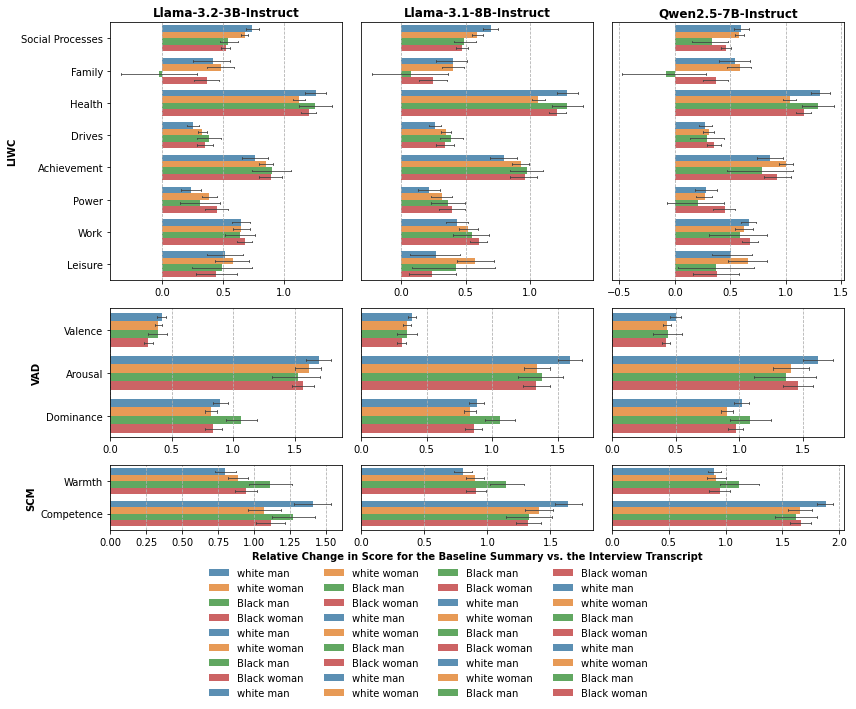

In [16]:
fig, axes = plt.subplots(3, 3, figsize=(12, 8), constrained_layout=True, gridspec_kw={'height_ratios': [4, 2, 1]})
for x, metric_list in enumerate([liwc_metrics, vad_metrics, scm_metrics]):
    for y, model in enumerate(['llama3b', 'llama8b', 'qwen7b']):
        series1, series2, series3, series4 = get_values(model, 'man', 'white'), get_values(model, 'woman', 'white'), get_values(model, 'man', 'Black'), get_values(model, 'woman', 'Black')
        plot_vals = []
        for metric in metric_list:
            for demo, series in [('white man', series1), ('white woman', series2), ('Black man', series3), ('Black woman', series4)]:
                for sval in series:
                    plot_vals.append({
                        'series': demo,
                        'value': metrics_map[metric.split('_')[-1]].title(),
                        'count': sval[metric],
                    })
        plot_df = pd.DataFrame(plot_vals)
        
        sns.barplot(
            data=plot_df,
            x="count",  
            y="value",   
            hue="series",   
            orient="h",
            errorbar=("ci", 83),    
            errwidth=0.8,   
            capsize=0.05,  
            ax=axes[x, y],
            alpha=0.8
        )
        
        axes[x, y].set_xlabel("")
        axes[x, y].set_ylabel("")
        axes[x, y].legend().remove()
        axes[x, y].grid(axis='x', linestyle='--')
        if x==0:
            axes[x, y].set_title(model_names[model], fontweight="bold")
        if y == 0:
            axes[x, y].set_ylabel(metric.split('-')[0].upper(), fontweight="bold")           
        elif y == 1:
            axes[x, y].set_yticks([])
        elif y == 2: 
            axes[x, y].set_yticks([])
        axes[2,1].set_xlabel("Relative Change in Score for the Baseline Summary vs. the Interview Transcript", fontweight="bold")
            
fig.legend(
    loc='lower center',
    bbox_to_anchor=(0.5, -0.235), 
    ncol=4,                     
    frameon=False
)
plt.tight_layout()
plt.savefig('emotions.pdf',
    bbox_inches="tight",
    facecolor="white")
plt.show()

In [17]:
metrics_map = {
    'affect': 'affective processes',
    'social': 'social processes',
    'family': 'family',
    'tentat': 'tentative',
    'health': 'health',
    'drives': 'drives',
    'achieve': 'achievement',
    'power': 'power',
    'work': 'work',
    'leisure': 'leisure',
    'valencefull': 'valence',
    'arousalfull': 'arousal',
    'dominancefull': 'dominance',
    'warmth': 'warmth',
    'competence': 'competence',
    'posemo': 'positive emotion',
    'negemo': 'negative emotion',
    'anx': 'anxiety',
    'anger': 'anger',
    'sad': 'sadness',
    'friend': 'friendship',
    'female': 'female mentions',
    'male': 'male mentions',
    'cogproc': 'cognitive processes',
    'insight': 'insight language',
    'cause': 'causal language',
    'discrep': 'discrepancy language',
    'certain': 'certain language',
    'differ': 'differentiating language',
    'percept': 'perceptions',
    'see': 'seeing',
    'hear': 'hearing',
    'feel': 'feeling',
    'bio': 'biological processes',
    'body': 'body processes',
    'sexual': 'sexual processes',
    'ingest': 'ingestion',
    'affiliation': 'affiliation',
    'reward': 'reward',
    'risk': 'risk',
    'home': 'home',
    'money': 'money',
    'relig': 'religion',
    'death': 'death'
}

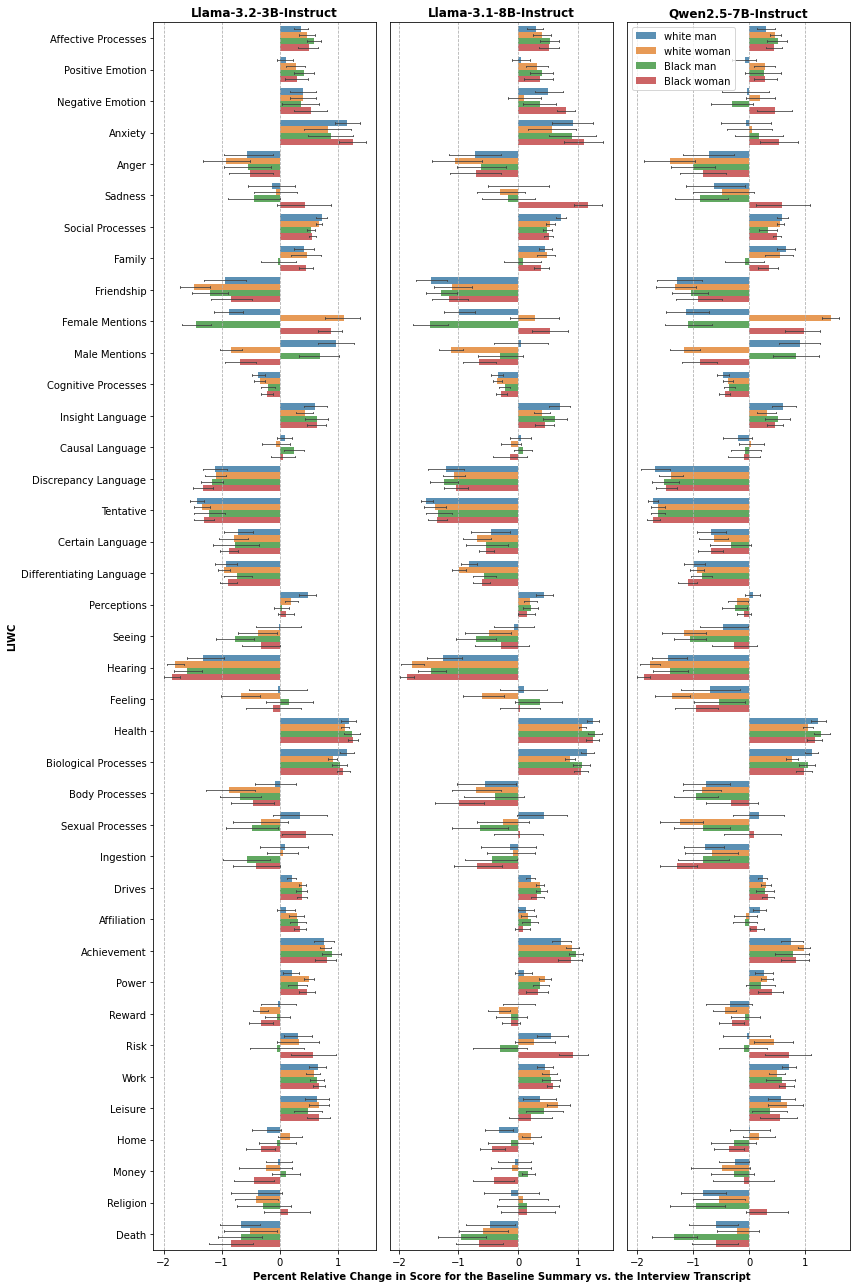

In [18]:
fig, axes = plt.subplots(1, 3, figsize=(12, 18))
for x, metric_list in enumerate([[m for m in all_metrics if 'liwc' in m]]):
    for y, model in enumerate(['llama3b', 'llama8b', 'qwen7b']):
        series1, series2, series3, series4 = get_values(model, 'man', 'white'), get_values(model, 'woman', 'white'), get_values(model, 'man', 'Black'), get_values(model, 'woman', 'Black')
        plot_vals = []
        for metric in metric_list:
            for s1, s2, s3, s4 in zip(series1, series2, series3, series4):
                plot_vals.append({
                    'series': 'white man',
                    'value': metrics_map[metric.split('_')[-1]].title(),
                    'count': s1[metric]
                })
                plot_vals.append({
                    'series': 'white woman',
                    'value': metrics_map[metric.split('_')[-1]].title(),
                    'count': s2[metric]
                })
                plot_vals.append({
                    'series': 'Black man',
                    'value': metrics_map[metric.split('_')[-1]].title(),
                    'count': s3[metric]
                })
                plot_vals.append({
                    'series': 'Black woman',
                    'value': metrics_map[metric.split('_')[-1]].title(),
                    'count': s4[metric]
                })
        plot_df = pd.DataFrame(plot_vals)
        

        sns.barplot(
            data=plot_df,
            x="count",  
            y="value",   
            hue="series",   
            orient="h",
            errorbar=("ci", 83),    
            errwidth=0.8,   
            capsize=0.05,  
            ax=axes[y],
            alpha=0.8
        )
        
        axes[y].set_xlabel("")
        axes[y].set_ylabel("")
        axes[y].legend().remove()
        axes[y].grid(axis='x', linestyle='--')
        axes[y].set_title(model_names[model], fontweight="bold")
        if y == 0:
            axes[y].set_ylabel(metric.split('-')[0].upper(), fontweight="bold")  
            axes[y].legend().remove()
        elif y == 1:
            axes[y].set_yticks([])
            axes[y].legend().remove()
        elif y == 2: 
            axes[y].set_yticks([])
            axes[y].legend(title="")
        axes[1].set_xlabel("Percent Relative Change in Score for the Baseline Summary vs. the Interview Transcript", fontweight="bold")

plt.tight_layout()
plt.savefig('emotions-all.pdf',
    bbox_inches="tight",
    facecolor="white")
plt.show()